# **Diseño de filtros para señales EMG y ECG**
## **1. Filtros EMG:**
### **1.1 Señal EMG 1: Elevación Trapecio descendente (superior)**
Filtro para señal EMG: pasabanda 40 - 350 Hz.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import lfilter
from tqdm import tqdm

# Parámetros y carga
Fs = 1000  # Hz
emg1 = np.loadtxt("Señales/EMG_1.txt", usecols=[-1])
t = np.arange(len(emg1)) / Fs

# Conversión ADC -> mV (BITalino EMG)
# Parametros típicos BITalino (r)evolution:
N_BITS = 10
ADC_MAX = (2**N_BITS - 1)  # 1023
VCC    = 3.3               # Volts
G_EMG  = 1009.0            # Ganancia aproximada del sensor EMG

emg_mV = ((emg1.astype(float) / ADC_MAX) - 0.5) * VCC / G_EMG * 1000.0  # mV

# Movimiento
inicio = int(10 * Fs)
fin    = int(20 * Fs)
x      = emg_mV[inicio:fin]      # señal en mV (Movimiento)
tt     = t[inicio:fin]

# Rectificar (quitar DC)
x = x - x.mean()

# Filtros a usar (coeficientes exportados de pyFDA)
filtros = [
    ("Butterworth",  "EMG_1.1_Butterworth.csv"),
    ("Bessel",       "EMG_1.2_Bessel.csv"),
    ("Chebyshev I",  "EMG_1.3_Chebyshev1.csv"),
    ("FIR Blackman", "EMG_1.4_FIR_Blackman.csv"),
]

# Aplicar cada filtro y guardar salidas
ys = []  # lista de (label, y_filtrada)
for label, csv in filtros:
    f = pd.read_csv(csv, names=["b", "a"])
    b = f["b"].to_numpy()
    if label == "FIR Blackman":
        a = np.array([1.0])  # FIR tiene a=1
    else:
        a = f["a"].to_numpy()
    y = lfilter(b, a, x)
    ys.append((label, y))

### **Comparación de Señal EMG: Antes vs después del filtrado**

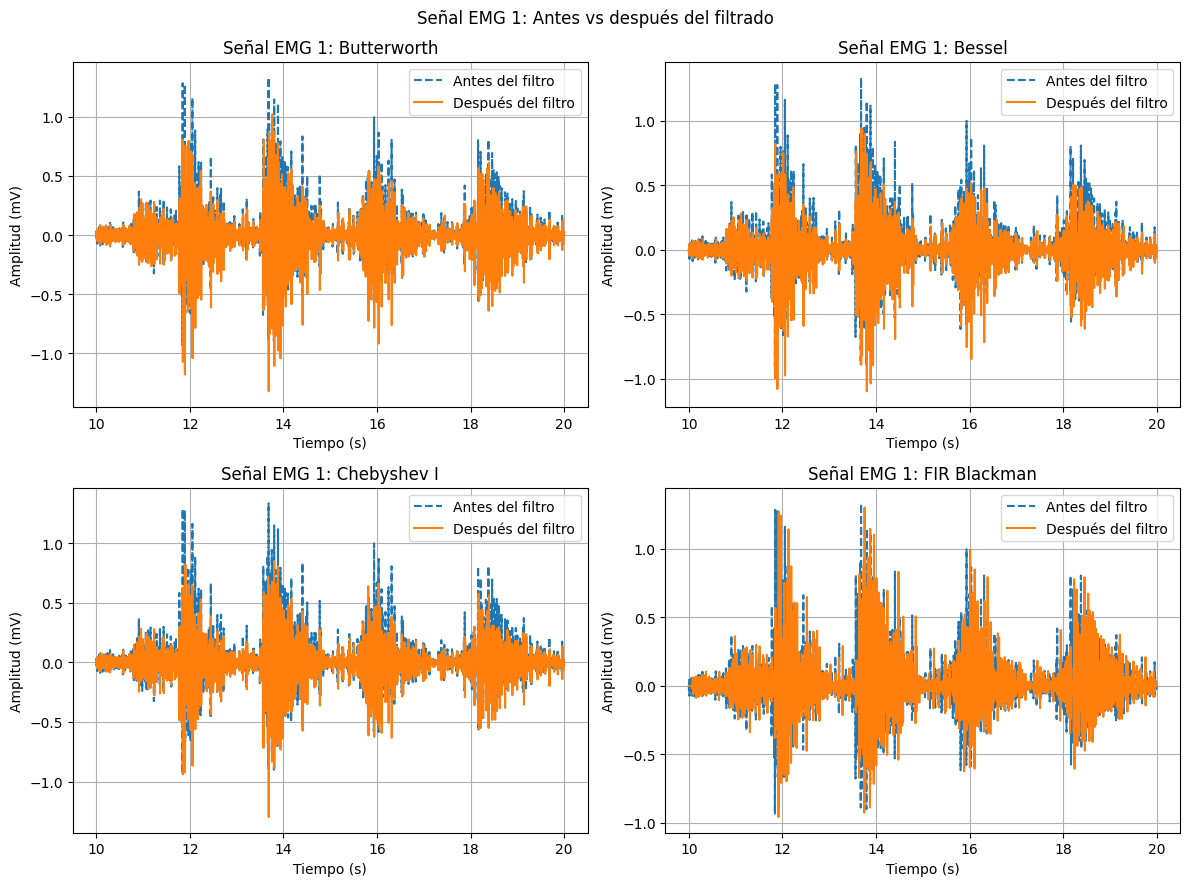

In [2]:
# 1. Señal antes vs después
plt.figure(figsize=(12, 9))
for i, (label, y) in enumerate(ys, start=1):
    plt.subplot(2, 2, i)
    plt.plot(tt, x, linestyle="--", label="Antes del filtro")
    plt.plot(tt, y, label="Después del filtro")
    plt.title(f"Señal EMG 1: {label}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud (mV)")
    plt.grid(True)
    plt.legend(loc="upper right")
plt.suptitle("Señal EMG 1: Antes vs después del filtrado")
plt.tight_layout()
plt.show()

### **Comparación de espectro de frecuencias: Antes vs después del filtrado**

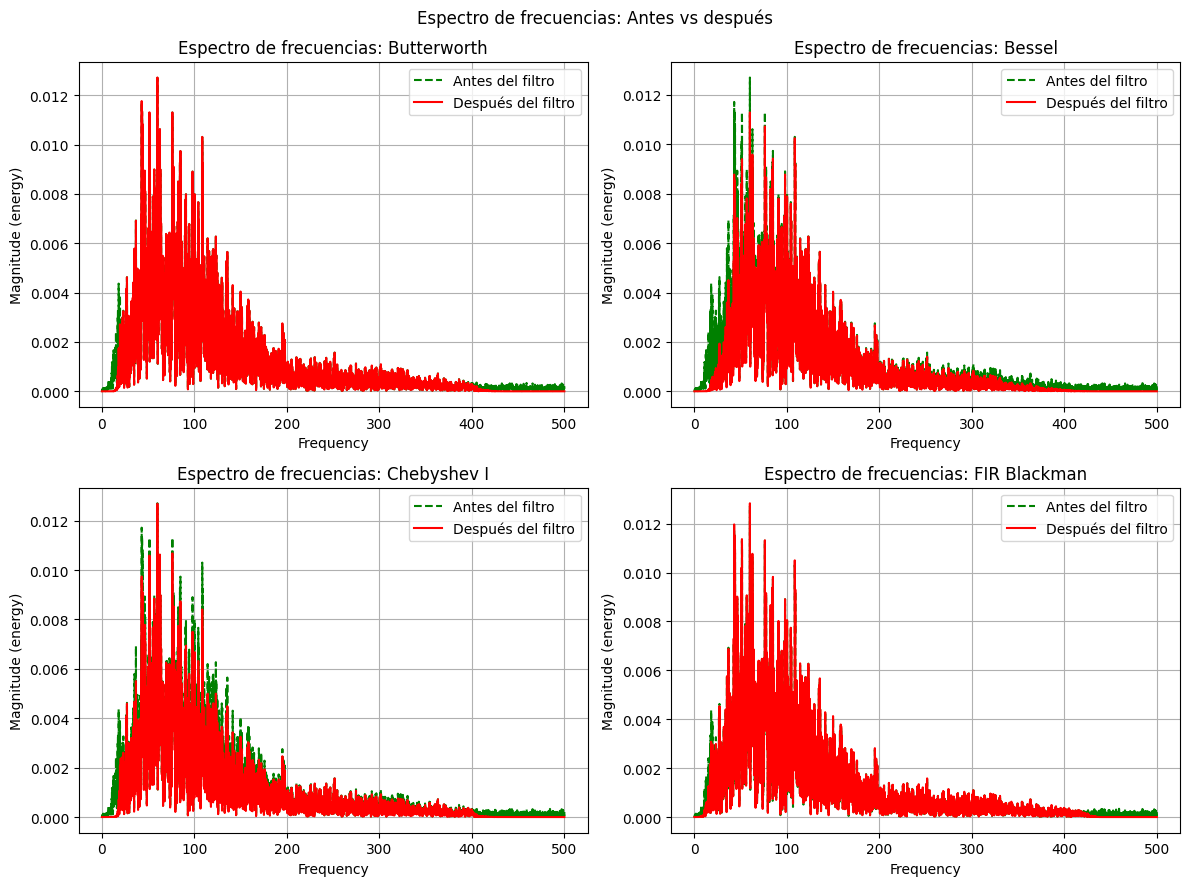

In [3]:
# 2. Espectro de frecuencias antes vs después
plt.figure(figsize=(12, 9))
for i, (label, y) in enumerate(ys, start=1):
    plt.subplot(2, 2, i)
    plt.magnitude_spectrum(x, Fs=Fs, color="green", ls="--", label="Antes del filtro")
    plt.magnitude_spectrum(y, Fs=Fs, color="red", label="Después del filtro")
    plt.title(f"Espectro de frecuencias: {label}")
    plt.grid(True)
    plt.legend(loc="upper right")
plt.suptitle("Espectro de frecuencias: Antes vs después")
plt.tight_layout()
plt.show()

### **Comparación de Magnitud (|H(f)|)**

<table>
  <tr>
    <td align="center">Butterworth<br>
      <img src="Filtros%20pyfda/EMG_1.1_magnitud.png" width="480">
    </td>
    <td align="center">Bessel<br>
      <img src="Filtros%20pyfda/EMG_1.2_magnitud.png" width="480">
    </td>
  </tr>
  <tr>
    <td align="center">Chebyshev I<br>
      <img src="Filtros%20pyfda/EMG_1.3_magnitud.png" width="480">
    </td>
    <td align="center">FIR Blackman<br>
      <img src="Filtros%20pyfda/EMG_1.4_magnitud.png" width="480">
    </td>
  </tr>
</table>

### **Comparación de Fase (∠H(f))**

<table>
  <tr>
    <td align="center">Butterworth<br>
      <img src="Filtros%20pyfda/EMG_1.1_fase.png" width="480">
    </td>
    <td align="center">Bessel<br>
      <img src="Filtros%20pyfda/EMG_1.2_fase.png" width="480">
    </td>
  </tr>
  <tr>
    <td align="center">Chebyshev I<br>
      <img src="Filtros%20pyfda/EMG_1.3_fase.png" width="480">
    </td>
    <td align="center">FIR Blackman<br>
      <img src="Filtros%20pyfda/EMG_1.4_fase.png" width="480">
    </td>
  </tr>
</table>
